# Embedding filters 2 — Diagonal Kalman

A Kalman filter on an embedding with a **random-walk** model
(`F = H = I`) and *diagonal* process/measurement noise. With diagonal
`Q`, `R` and a diagonal initial covariance the per-dimension filters
are independent, so the cost stays `O(D)` while — unlike EMA — the
filter carries a real uncertainty that *adapts* the gain: it trusts
measurements more while uncertain (early frames) and less once
confident.

We build it from `KalmanLinear` + `KalmanUpdate` (the same primitives
as the motion Kalman, just with identity dynamics) and track the
per-dimension variance shrinking.


In [1]:
import torch
import matplotlib.pyplot as plt

import unitrack
from unitrack.assignment import Associate, Jonker
from unitrack.costs import Cosine
from unitrack.data import Detections, FrameContext, TensorSpec
from unitrack.lifecycle import IncludeAll, NoLifecycle
from unitrack.pipeline import Pipe

torch.manual_seed(0)

D = 16          # embedding dimensionality (256+ in practice; 16 plots fast)
T = 44          # frames

def make_clip(noise=0.15, seed=0, switch=None):
    """
    A unit embedding that rotates slowly in the (e0, e1) plane plus
    per-frame noise in all D dims. Rotating in a known plane means
    projecting onto dims (0, 1) shows the true path as a circle arc.
    `switch` optionally rotates the plane mid-clip (an appearance change).
    """
    g = torch.Generator().manual_seed(seed)
    t = torch.arange(T).float()
    theta = 0.10 * t
    truth = torch.zeros(T, D)
    truth[:, 0] = torch.cos(theta)
    truth[:, 1] = torch.sin(theta)
    if switch is not None:
        # after `switch`, swap appearance into the (e2, e3) plane.
        truth[switch:, :] = 0.0
        truth[switch:, 2] = torch.cos(theta[switch:])
        truth[switch:, 3] = torch.sin(theta[switch:])
    obs = truth + noise * torch.randn(T, D, generator=g)
    obs = torch.nn.functional.normalize(obs, dim=-1)
    dets = [Detections(index=torch.tensor([0]), emb=obs[k:k + 1].clone(),
                       batch_size=[1]) for k in range(T)]
    return t, truth, obs, dets

def run(tracker, dets, fields=("emb",)):
    """Run a single-object clip through a real Tracker; collect snapshot fields."""
    ms = unitrack.MultiStream(tracker)
    rec = {f: [] for f in fields}
    for k, d in enumerate(dets):
        ctx = FrameContext.make(frame_idx=k, delta=1.0, fps=1.0, stream_key=0)
        res = ms.step(stream_key=0, detections=d, ctx=ctx)
        for f in fields:
            rec[f].append(getattr(res.snapshot, f)[0].clone())
    return {f: torch.stack(v) for f, v in rec.items()}

def cos_to_truth(est, truth):
    e = torch.nn.functional.normalize(est, dim=-1)
    u = torch.nn.functional.normalize(truth, dim=-1)
    return (e * u).sum(-1)

t, truth, obs, dets = make_clip()
print(f"clip: {T} frames, D={D}; raw-detection mean cosine-to-truth "
      f"= {cos_to_truth(obs, truth).mean():.3f}")


clip: 44 frames, D=16; raw-detection mean cosine-to-truth = 0.855


In [2]:
from unitrack.states import FromDetectionField, State
from unitrack.states import EyeInitializer, NoopObservation, NoopProcess
from unitrack.states.kalman import KalmanLinear, KalmanUpdate

def diagonal_kalman_tracker(q=0.02, r=0.2, init_var=1.0):
    eye = torch.eye(D)
    states = {
        "emb": State(
            schema=TensorSpec(shape=(D,), dtype=torch.float32),
            process=KalmanLinear(field="emb", F=eye, H=eye,
                                 Q=eye * q, R=eye * r),
            observation=KalmanUpdate(field="emb", cov_field="emb_cov",
                                     H=eye, R=eye * r),
            init=FromDetectionField("emb"),
        ),
        "emb_cov": State(
            schema=TensorSpec(shape=(D, D), dtype=torch.float32),
            process=NoopProcess(), observation=NoopObservation(),
            init=EyeInitializer(dim=D, scale=init_var),
        ),
    }
    return unitrack.Tracker(
        root=Pipe(cost=Cosine("emb"), assoc=Associate(Jonker(threshold=0.6))),
        states=states, lifecycle=NoLifecycle(), visibility=IncludeAll(),
    )

rec = run(diagonal_kalman_tracker(), dets, fields=("emb", "emb_cov"))


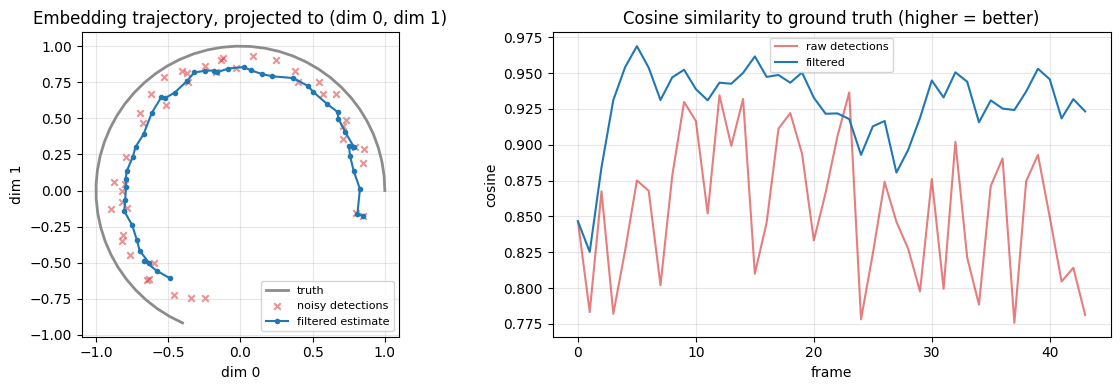

raw mean cos = 0.855   filtered mean cos = 0.928


In [3]:
fig, (axp, axc) = plt.subplots(1, 2, figsize=(12, 4))
axp.plot(truth[:, 0], truth[:, 1], "-", color="0.55", lw=2, label="truth")
axp.scatter(obs[:, 0], obs[:, 1], marker="x", color="tab:red", s=22,
            alpha=0.5, label="noisy detections")
axp.plot(rec["emb"][:, 0], rec["emb"][:, 1], "o-", color="tab:blue",
         ms=3, label="filtered estimate")
axp.set_title("Embedding trajectory, projected to (dim 0, dim 1)")
axp.set_xlabel("dim 0"); axp.set_ylabel("dim 1")
axp.legend(fontsize=8); axp.grid(alpha=0.3); axp.set_aspect("equal")

axc.plot(t, cos_to_truth(obs, truth), color="tab:red", alpha=0.6,
         label="raw detections")
axc.plot(t, cos_to_truth(rec["emb"], truth), color="tab:blue",
         label="filtered")
axc.set_title("Cosine similarity to ground truth (higher = better)")
axc.set_xlabel("frame"); axc.set_ylabel("cosine"); axc.legend(fontsize=8)
axc.grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"raw mean cos = {cos_to_truth(obs, truth).mean():.3f}   "
      f"filtered mean cos = {cos_to_truth(rec['emb'], truth).mean():.3f}")


## Adaptive gain via the covariance

The variance starts high (the filter knows it is guessing) and
collapses as evidence accumulates — that shrinking is what makes the
Kalman gain large early and small later, the behaviour EMA's fixed
`rho` only approximates. The covariance stays diagonal throughout
(diagonal `Q`/`R`/`P0`), so this is genuinely `O(D)`.


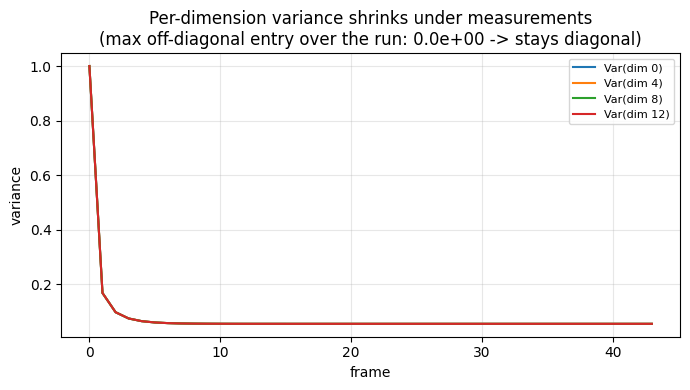

In [4]:
var = torch.stack([rec["emb_cov"][k].diagonal() for k in range(T)])  # (T, D)
offdiag = torch.stack([
    (rec["emb_cov"][k] - torch.diag(rec["emb_cov"][k].diagonal())).abs().max()
    for k in range(T)])
fig, ax = plt.subplots(figsize=(7, 4))
for j in range(0, D, 4):
    ax.plot(t, var[:, j], label=f"Var(dim {j})")
ax.set_title(f"Per-dimension variance shrinks under measurements\n"
             f"(max off-diagonal entry over the run: {offdiag.max():.1e} "
             f"-> stays diagonal)")
ax.set_xlabel("frame"); ax.set_ylabel("variance")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Takeaway.** A diagonal Kalman gives EMA-like cost with principled,
adaptive, *measurable* uncertainty. When you need the full covariance
but `D` is large, the information filter and the EnKF (notebook 4)
scale better.
